# YOLO segmentation для тарелок


In [1]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130

Looking in indexes: https://download.pytorch.org/whl/cu130
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from PIL import Image
from ultralytics import YOLO

print(torch.__version__)
print(torch.cuda.is_available())

SEED = 451
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "plate_yolo_seg").exists() else cwd.parent
DATASET_DIR = PROJECT_ROOT / "plate_yolo_seg"
DATA_YAML = DATASET_DIR / "data.yaml"

assert DATA_YAML.exists(), f"Не найден data.yaml: {DATA_YAML}"
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_YAML: {DATA_YAML}")
print(f"CUDA: {torch.cuda.is_available()}")

2.9.0+cu130
True
PROJECT_ROOT: C:\Projects\FoodProject\FoodProject
DATA_YAML: C:\Projects\FoodProject\FoodProject\plate_yolo_seg\data.yaml
CUDA: True


In [3]:
with DATA_YAML.open("r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

print(data_cfg)

def validate_split(split: str) -> None:
    image_dir = DATASET_DIR / "images" / split
    label_dir = DATASET_DIR / "labels" / split
    images = sorted([p for p in image_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}])
    labels = sorted(label_dir.glob("*.txt"))
    image_stems = {p.stem for p in images}
    label_stems = {p.stem for p in labels}
    missing_labels = sorted(image_stems - label_stems)
    orphan_labels = sorted(label_stems - image_stems)
    bad_labels = []

    for label in labels:
        for line_no, raw_line in enumerate(label.read_text(encoding="utf-8").splitlines(), 1):
            parts = raw_line.strip().split()
            if not parts:
                continue
            if len(parts) < 7 or len(parts[1:]) % 2 != 0:
                bad_labels.append(f"{label.name}:{line_no}: неверное число координат")
                continue
            coords = np.array(parts[1:], dtype=float)
            if coords.min() < 0 or coords.max() > 1:
                bad_labels.append(f"{label.name}:{line_no}: координаты вне [0, 1]")

    print(f"{split}: images={len(images)}, labels={len(labels)}")
    assert not missing_labels, f"{split}: нет labels для {missing_labels[:10]}"
    assert not orphan_labels, f"{split}: labels без images {orphan_labels[:10]}"
    assert not bad_labels, "\n".join(bad_labels[:20])

validate_split("train")
validate_split("val")

{'path': 'C:/Projects/FoodProject/FoodProject/plate_yolo_seg', 'train': 'images/train', 'val': 'images/val', 'names': {0: 'plate'}}
train: images=159, labels=159
val: images=40, labels=40


## Быстрый просмотр масок

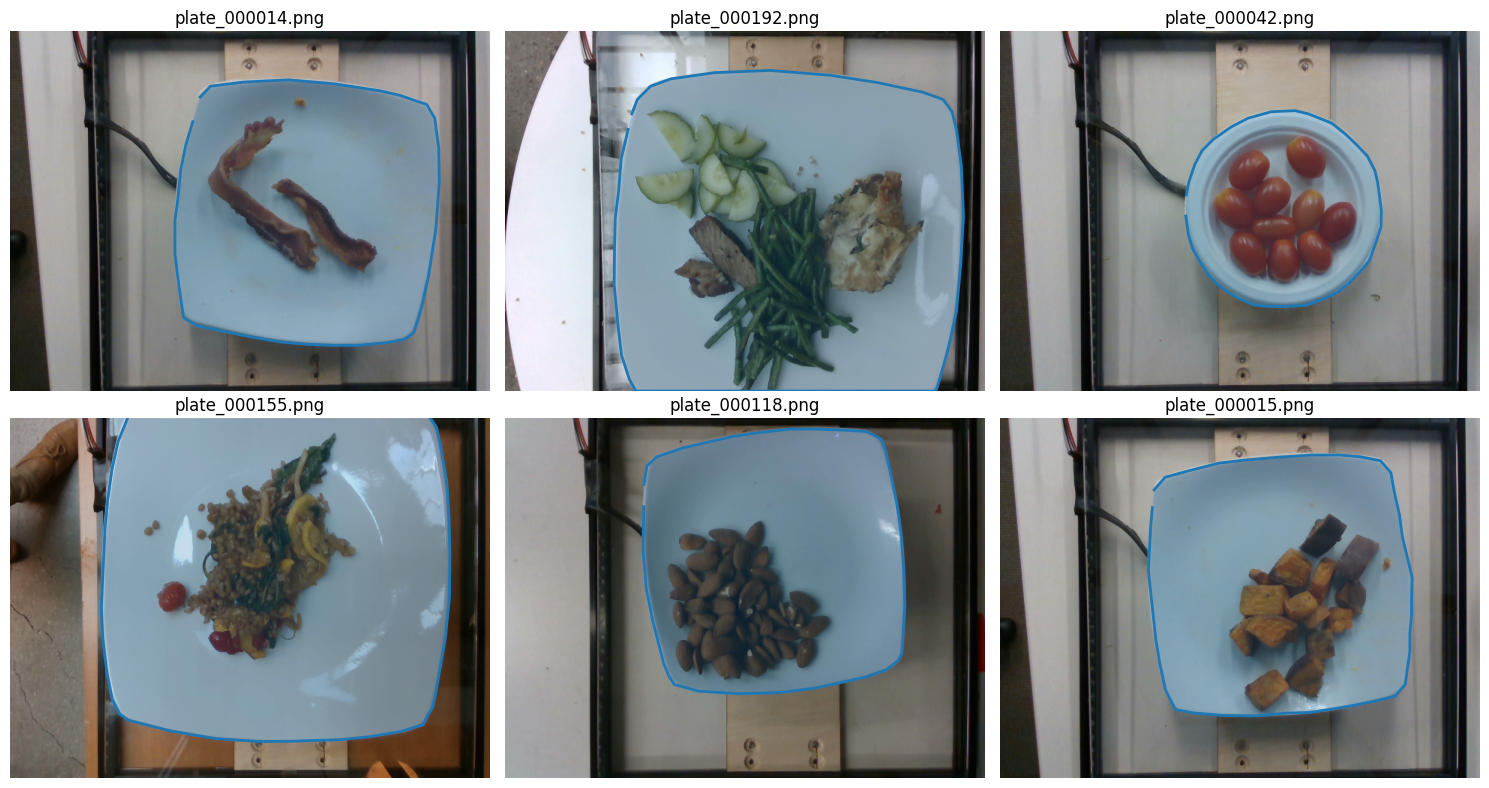

In [4]:
def draw_yolo_seg_sample(split: str = "train", n: int = 6) -> None:
    image_dir = DATASET_DIR / "images" / split
    label_dir = DATASET_DIR / "labels" / split
    images = sorted([p for p in image_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}])
    samples = random.sample(images, min(n, len(images)))

    cols = 3
    rows = int(np.ceil(len(samples) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, image_path in zip(axes, samples):
        image = Image.open(image_path).convert("RGB")
        w, h = image.size
        ax.imshow(image)
        label_path = label_dir / f"{image_path.stem}.txt"
        for line in label_path.read_text(encoding="utf-8").splitlines():
            parts = line.strip().split()
            if not parts:
                continue
            coords = np.array(parts[1:], dtype=float).reshape(-1, 2)
            coords[:, 0] *= w
            coords[:, 1] *= h
            ax.fill(coords[:, 0], coords[:, 1], alpha=0.25)
            ax.plot(coords[:, 0], coords[:, 1], linewidth=2)
        ax.set_title(image_path.name)
        ax.axis("off")

    for ax in axes[len(samples):]:
        ax.axis("off")
    plt.tight_layout()

draw_yolo_seg_sample("train")

## Обучение

Ограничения от оверфита для маленького датасета: `patience`, валидационный split, `weight_decay`, `dropout`, `cos_lr`, `freeze`, умеренный `mosaic` с `close_mosaic`, небольшая модель и сохранение лучшей эпохи по validation metric.

In [5]:
model = YOLO("yolo26s-seg.pt")

results = model.train(
    data=str(DATA_YAML),
    task="segment",
    imgsz=640,
    epochs=200,
    batch=8,
    device=0,
    workers=4,
    project=str(PROJECT_ROOT / "plate_segmentation" / "runs"),
    name="plate_yolo_seg",
    exist_ok=True,
    pretrained=True,
    single_cls=True,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.001,
    dropout=0.15,
    momentum=0.937,
    warmup_epochs=5,
    cos_lr=True,
    patience=30,
    freeze=10,
    close_mosaic=20,
    hsv_h=0.015,
    hsv_s=0.45,
    hsv_v=0.35,
    degrees=10.0,
    translate=0.08,
    scale=0.35,
    shear=2.0,
    perspective=0.0005,
    fliplr=0.5,
    flipud=0.0,
    mosaic=0.5,
    mixup=0.05,
    copy_paste=0.1,
    mask_ratio=4,
    overlap_mask=True,
    retina_masks=True,
    save=True,
    save_period=10,
    plots=True,
    seed=SEED,
    deterministic=True,
    verbose=True,
)

best_model_path = Path(results.save_dir) / "weights" / "best.pt"
print(f"best model: {best_model_path}")

New https://pypi.org/project/ultralytics/8.4.55 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.53  Python-3.14.2 torch-2.9.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Projects\FoodProject\FoodProject\plate_yolo_seg\data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.15, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.45, hsv_v=0.35, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolo26s-seg.pt, mom

## Валидация лучшей модели

In [8]:
best_model = YOLO(str(best_model_path))
metrics = best_model.val(
    data=str(DATA_YAML),
    imgsz=640,
    batch=8,
    device=0,
    split="val",
    plots=True,
    retina_masks=True,
)
metrics

Ultralytics 8.4.53  Python-3.14.2 torch-2.9.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
YOLO26s-seg summary (fused): 139 layers, 10,365,727 parameters, 0 gradients, 34.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1282.4453.7 MB/s, size: 433.6 KB)
val: Scanning C:\Projects\FoodProject\FoodProject\plate_yolo_seg\labels\val.cache... 40 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40 14.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.9it/s 2.7s0.3ss
                   all         40         40      0.998          1      0.995      0.992      0.998          1      0.995      0.995
Speed: 2.2ms preprocess, 11.7ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to C:\Projects\FoodProject\FoodProject\plate_segmentation\runs\segment\val


ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000269C6745710>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.0410

## Проверка инференса на validation изображениях


0: 480x640 1 item, 14.0ms
1: 480x640 1 item, 14.0ms
2: 480x640 1 item, 14.0ms
3: 480x640 1 item, 14.0ms
4: 480x640 1 item, 14.0ms
5: 480x640 1 item, 14.0ms
Speed: 1.6ms preprocess, 14.0ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Results saved to C:\Projects\FoodProject\FoodProject\plate_segmentation\runs\plate_yolo_seg_predict


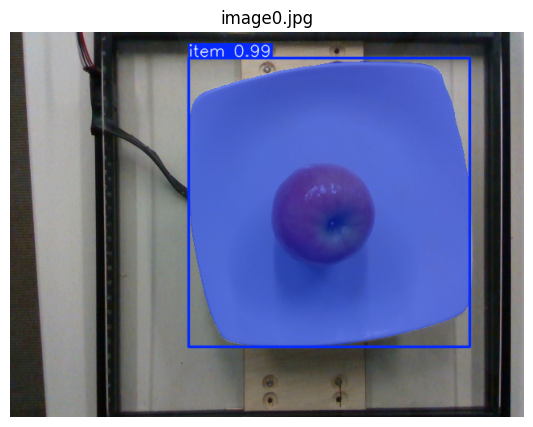

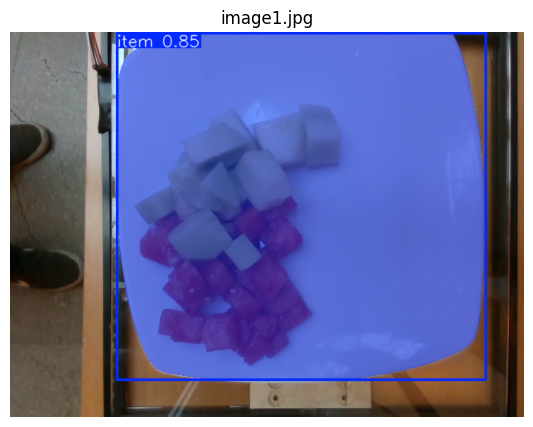

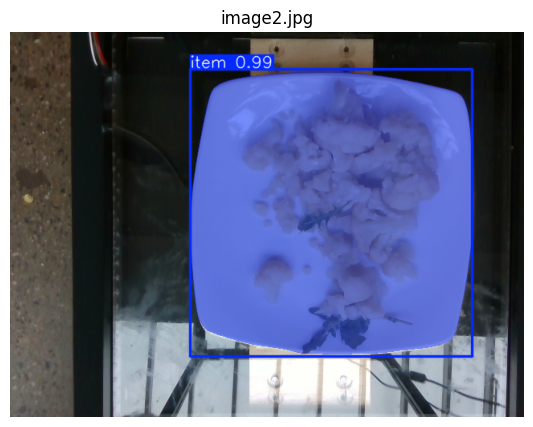

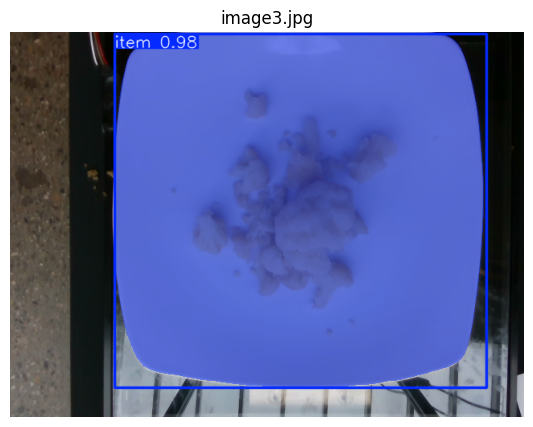

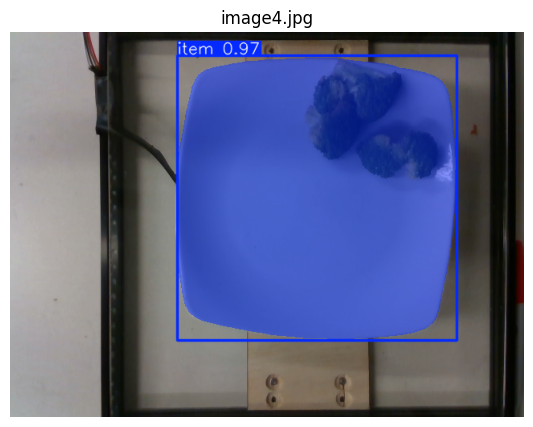

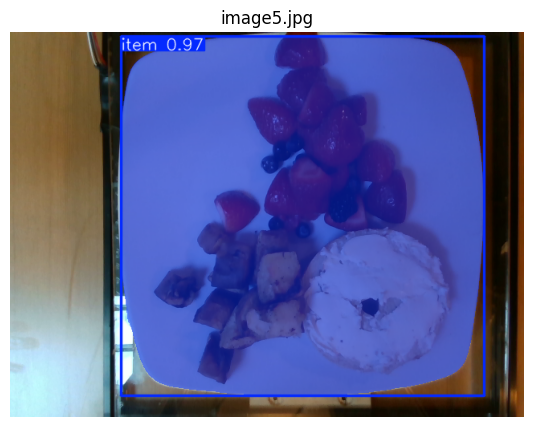

: 

In [ ]:
val_images = sorted((DATASET_DIR / "images" / "val").glob("*"))
sample_images = random.sample(val_images, min(6, len(val_images)))

predictions = best_model.predict(
    source=[str(p) for p in sample_images],
    imgsz=640,
    conf=0.25,
    iou=0.6,
    retina_masks=True,
    save=True,
    project=str(PROJECT_ROOT / "plate_segmentation" / "runs"),
    name="plate_yolo_seg_predict",
    exist_ok=True,
)

for result in predictions:
    rendered = result.plot()
    plt.figure(figsize=(7, 5))
    plt.imshow(rendered[..., ::-1])
    plt.title(Path(result.path).name)
    plt.axis("off")
    plt.show()